Imports & Load Data

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf
from pathlib import Path
%matplotlib inline
sns.set_style('whitegrid')

# Load raw BTC data
df = pd.read_csv('../data/raw/btc_1h_lib.csv')
# If open_time is in milliseconds (as returned by python-binance)
df['open_time'] = pd.to_datetime(df['open_time'], unit='ms')
# Set datetime index
df.set_index('open_time', inplace=True)
df = df[['open', 'high', 'low', 'close', 'volume']].astype(float)

print(df.shape)
print(df.head())
print(df.describe())


(54265, 5)
                        open     high      low    close      volume
open_time                                                          
2020-01-01 00:00:00  7195.24  7196.25  7175.46  7177.02  511.814901
2020-01-01 01:00:00  7176.47  7230.00  7175.71  7216.27  883.052603
2020-01-01 02:00:00  7215.52  7244.87  7211.41  7242.85  655.156809
2020-01-01 03:00:00  7242.66  7245.00  7220.00  7225.01  783.724867
2020-01-01 04:00:00  7225.00  7230.00  7215.03  7217.27  467.812578
                open           high            low          close   
count   54265.000000   54265.000000   54265.000000   54265.000000  \
mean    48144.578200   48333.863454   47946.374517   48145.732024   
std     31464.106145   31552.958598   31372.003836   31463.752333   
min      4131.230000    4610.000000    3782.130000    4130.640000   
25%     22718.330000   22822.810000   22600.000000   22719.250000   
50%     41368.680000   41555.000000   41156.900000   41370.250000   
75%     66895.990000   67143.6

Price & Volume Trends

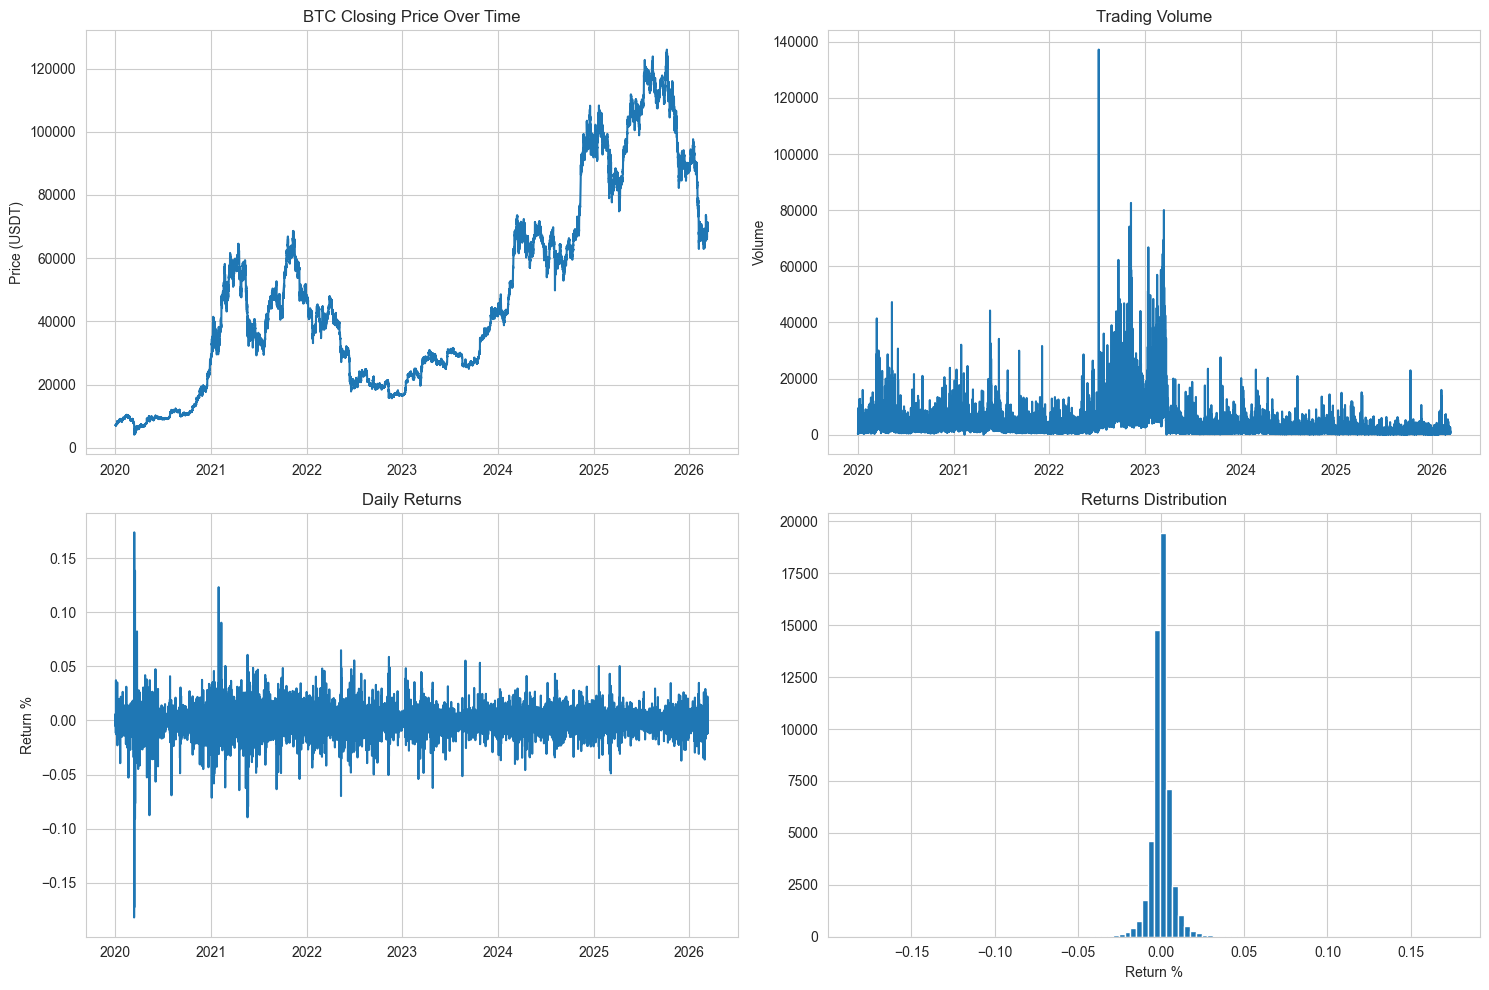

In [6]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.plot(df.index, df['close'])
plt.title('BTC Closing Price Over Time')
plt.ylabel('Price (USDT)')

plt.subplot(2, 2, 2)
plt.plot(df.index, df['volume'])
plt.title('Trading Volume')
plt.ylabel('Volume')

plt.subplot(2, 2, 3)
df['returns'] = df['close'].pct_change()
plt.plot(df.index, df['returns'])
plt.title('Daily Returns')
plt.ylabel('Return %')

plt.subplot(2, 2, 4)
plt.hist(df['returns'].dropna(), bins=100)
plt.title('Returns Distribution')
plt.xlabel('Return %')
plt.tight_layout()
plt.show()


Candlestick Chart (Recent 500 candles)

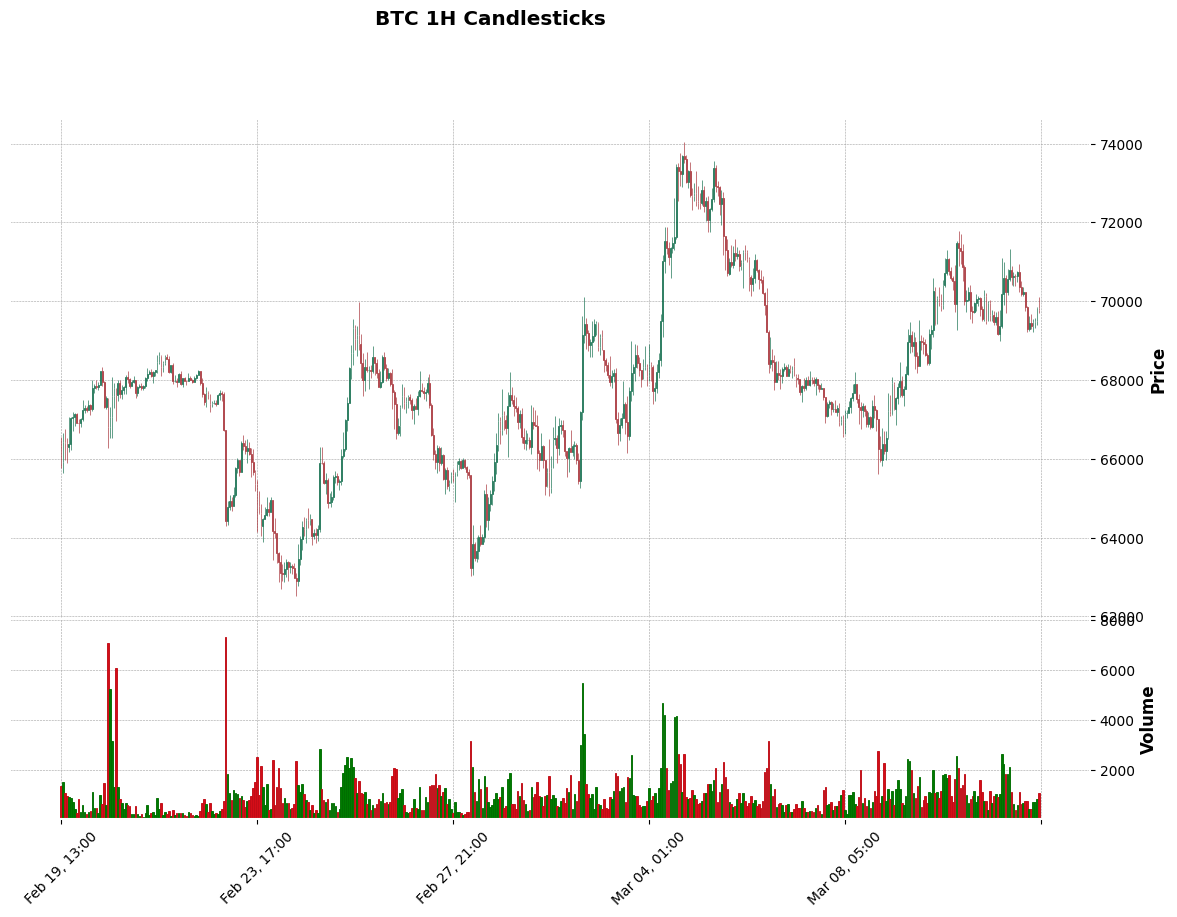

In [7]:
mpf.plot(df.tail(500), type='candle', style='charles', volume=True, title='BTC 1H Candlesticks', figsize=(15,10))


Key Metrics

Volatility Stats:
count    54242.000000
mean       459.705857
std        441.594233
min          7.993307
25%        138.157764
50%        333.590273
75%        630.290075
max       4035.770189
Name: volatility, dtype: float64

HL Range (%):
count    54265.000000
mean         0.867715
std          0.824890
min          0.000000
25%          0.406551
50%          0.652512
75%          1.060458
max         30.829643
Name: hl_range, dtype: float64


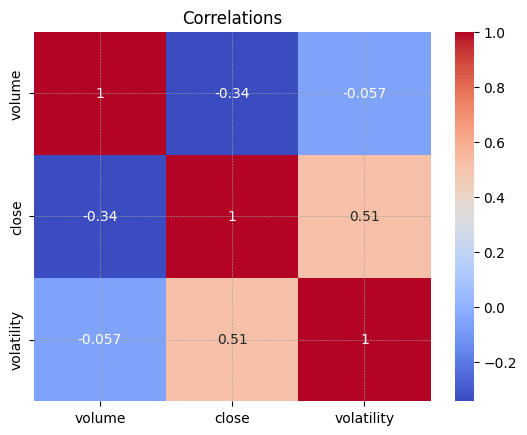

In [8]:
# Volatility
df['volatility'] = df['close'].rolling(24).std()  # 24h rolling
print("Volatility Stats:")
print(df['volatility'].describe())

# High-Low Range
df['hl_range'] = (df['high'] - df['low']) / df['close'] * 100
print("\nHL Range (%):")
print(df['hl_range'].describe())

# Volume-Price Correlation
corr = df[['volume', 'close', 'volatility']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlations')
plt.show()


Resample to Daily

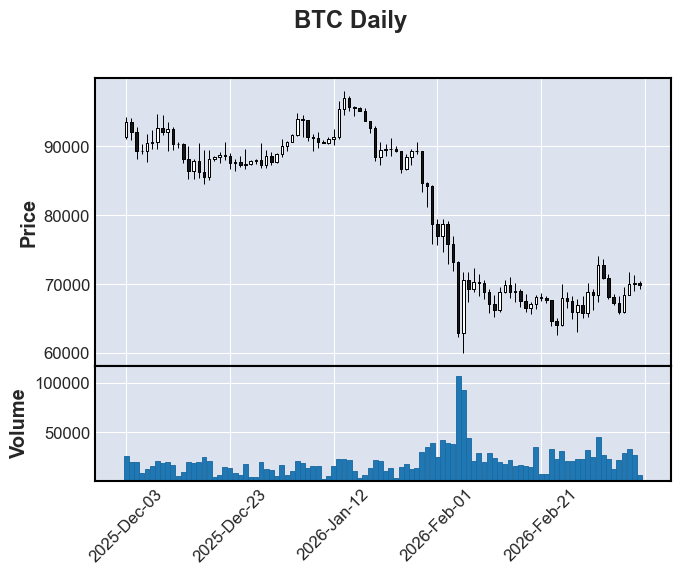

In [11]:
daily = df.resample('D').agg({'open': 'first', 'high': 'max', 'low': 'min', 'close': 'last', 'volume': 'sum'})
mpf.plot(daily.tail(100), type='candle', volume=True, title='BTC Daily')
